# Cross-validated hyperparameter selection

Replaces `2_regularized_regression.ipynb`/`3_elastic_net.ipynb`'s single train/validation-split alpha (and alpha/l1_ratio) sweeps with 5-fold cross-validation, for every regularized model (`RidgeGD`/sklearn `Ridge`, `LassoGD`/sklearn `Lasso`, `ElasticNetGD`/sklearn `ElasticNet`) -- per `docs/superpowers/specs/2026-09-06-cross-validation-design.md`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split

from ames_price.constants import NOMINAL_COLS, NUMERIC_COLS, ORDINAL_COLS
from ames_price.model_selection import kfold_split
from ames_price.models.elastic_net_gd import ElasticNetGD
from ames_price.models.lasso_gd import LassoGD
from ames_price.models.linear_regression import LinearRegressionGD
from ames_price.models.ridge_gd import RidgeGD
from ames_price.pipeline import build_pipeline

FEATURE_COLS = NUMERIC_COLS + ORDINAL_COLS + NOMINAL_COLS

## Load data, drop outliers, build the target, split CV pool vs. final holdout

`Id` 524/1299 dropped, target is `log_sale_price`, same as notebooks 1-3. The 80/20 split below uses the same `random_state=42` as notebooks 2/3's own train/validation split, so this notebook's final holdout is the exact same rows -- CV only ever touches the 80% `cv_pool`; the holdout stays untouched until the final metrics table.

In [2]:
df_train = pd.read_csv("../../data/train.csv")
df_train = df_train[~df_train["Id"].isin([524, 1299])]

X_raw = df_train[FEATURE_COLS]
y = np.log1p(df_train["SalePrice"]).to_numpy()

cv_pool_raw, holdout_raw, y_cv_pool, y_holdout = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)
cv_pool_raw.shape, holdout_raw.shape

((1166, 79), (292, 79))

## Cross-validation helper

`cv_scores` fits a fresh `build_pipeline()` inside every fold -- `StandardScaler`'s mean/std must never see that fold's held-out rows, even indirectly through statistics computed over the whole `cv_pool`. `model_cls(**model_kwargs)` is likewise constructed fresh per fold, so no fitted state leaks between folds. Returns one RMSE (log space) per fold; every sweep below reduces this to a mean and std.

In [3]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def cv_scores(model_cls, model_kwargs, X_raw, y, n_splits=5, random_state=42):
    fold_rmses = []
    folds = kfold_split(len(X_raw), n_splits, random_state)
    for train_idx, val_idx in folds:
        pipeline = build_pipeline()
        X_fold_train = pipeline.fit_transform(
            X_raw.iloc[train_idx]
        ).to_numpy()
        X_fold_val = pipeline.transform(X_raw.iloc[val_idx]).to_numpy()
        y_fold_train, y_fold_val = y[train_idx], y[val_idx]

        model = model_cls(**model_kwargs)
        model.fit(X_fold_train, y_fold_train)
        fold_rmses.append(rmse(y_fold_val, model.predict(X_fold_val)))

    return np.array(fold_rmses)

## Ridge/Lasso: 5-fold CV over alpha

Same `alphas_gd`/`alphas_sk` ranges as `2_regularized_regression.ipynb` -- sklearn `Ridge`'s own minimum sits near alpha=30 there, past `alphas_gd`'s range, so it alone sweeps the wider `alphas_sk`; `RidgeGD`, `LassoGD`, and sklearn `Lasso` all sweep `alphas_gd`.

In [4]:
alphas_gd = np.logspace(-3, 1, 9)
alphas_sk = np.logspace(-3, 3, 9)

ridge_gd_cv_mean, ridge_gd_cv_std = [], []
lasso_gd_cv_mean, lasso_gd_cv_std = [], []
lasso_sk_cv_mean, lasso_sk_cv_std = [], []

for a in alphas_gd:
    scores = cv_scores(
        RidgeGD,
        dict(
            learning_rate=0.01, batch_size=32, n_epochs=300,
            alpha=a, random_state=42,
        ),
        cv_pool_raw, y_cv_pool,
    )
    ridge_gd_cv_mean.append(scores.mean())
    ridge_gd_cv_std.append(scores.std())

    scores = cv_scores(
        LassoGD,
        dict(
            learning_rate=0.01, batch_size=32, n_epochs=300,
            alpha=a, random_state=42,
        ),
        cv_pool_raw, y_cv_pool,
    )
    lasso_gd_cv_mean.append(scores.mean())
    lasso_gd_cv_std.append(scores.std())

    scores = cv_scores(Lasso, dict(alpha=a), cv_pool_raw, y_cv_pool)
    lasso_sk_cv_mean.append(scores.mean())
    lasso_sk_cv_std.append(scores.std())

ridge_sk_cv_mean, ridge_sk_cv_std = [], []
for a in alphas_sk:
    scores = cv_scores(Ridge, dict(alpha=a), cv_pool_raw, y_cv_pool)
    ridge_sk_cv_mean.append(scores.mean())
    ridge_sk_cv_std.append(scores.std())

ridge_gd_cv_mean = np.array(ridge_gd_cv_mean)
ridge_gd_cv_std = np.array(ridge_gd_cv_std)
ridge_sk_cv_mean = np.array(ridge_sk_cv_mean)
ridge_sk_cv_std = np.array(ridge_sk_cv_std)
lasso_gd_cv_mean = np.array(lasso_gd_cv_mean)
lasso_gd_cv_std = np.array(lasso_gd_cv_std)
lasso_sk_cv_mean = np.array(lasso_sk_cv_mean)
lasso_sk_cv_std = np.array(lasso_sk_cv_std)

## Ridge/Lasso: mean CV RMSE vs. alpha

The CV analogue of notebook 2's `semilogx` line plot -- error bars are the std across the 5 folds, the direct visual signal of how noisy each alpha's score is.

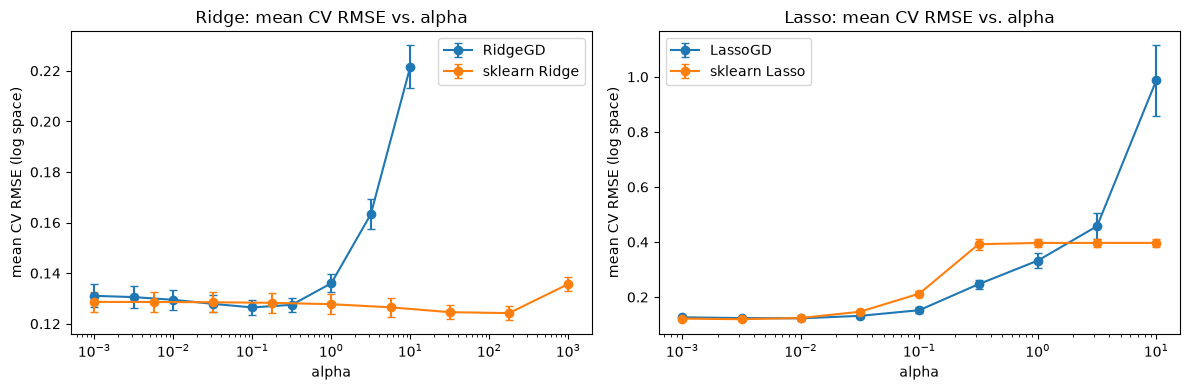

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].errorbar(
    alphas_gd, ridge_gd_cv_mean, yerr=ridge_gd_cv_std,
    marker="o", capsize=3, label="RidgeGD",
)
axes[0].errorbar(
    alphas_sk, ridge_sk_cv_mean, yerr=ridge_sk_cv_std,
    marker="o", capsize=3, label="sklearn Ridge",
)
axes[0].set_xscale("log")
axes[0].set_xlabel("alpha")
axes[0].set_ylabel("mean CV RMSE (log space)")
axes[0].set_title("Ridge: mean CV RMSE vs. alpha")
axes[0].legend()

axes[1].errorbar(
    alphas_gd, lasso_gd_cv_mean, yerr=lasso_gd_cv_std,
    marker="o", capsize=3, label="LassoGD",
)
axes[1].errorbar(
    alphas_gd, lasso_sk_cv_mean, yerr=lasso_sk_cv_std,
    marker="o", capsize=3, label="sklearn Lasso",
)
axes[1].set_xscale("log")
axes[1].set_xlabel("alpha")
axes[1].set_ylabel("mean CV RMSE (log space)")
axes[1].set_title("Lasso: mean CV RMSE vs. alpha")
axes[1].legend()

plt.tight_layout()
plt.show()

## ElasticNet: 5-fold CV over (alpha, l1_ratio)

Same 5x5 grid as `3_elastic_net.ipynb`.

In [6]:
alphas_en = np.logspace(-3, 1, 5)
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

en_gd_cv_mean = np.zeros((len(alphas_en), len(l1_ratios)))
en_sk_cv_mean = np.zeros((len(alphas_en), len(l1_ratios)))

for i, a in enumerate(alphas_en):
    for j, r in enumerate(l1_ratios):
        scores = cv_scores(
            ElasticNetGD,
            dict(
                learning_rate=0.01, batch_size=32, n_epochs=300,
                alpha=a, l1_ratio=r, random_state=42,
            ),
            cv_pool_raw, y_cv_pool,
        )
        en_gd_cv_mean[i, j] = scores.mean()

        scores = cv_scores(
            ElasticNet, dict(alpha=a, l1_ratio=r), cv_pool_raw, y_cv_pool,
        )
        en_sk_cv_mean[i, j] = scores.mean()

/home/kritagya/ml/ames-price/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.635667e-02, tolerance: 1.423e-02
  model = cd_fast.enet_coordinate_descent(
/home/kritagya/ml/ames-price/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.568728e-02, tolerance: 1.444e-02
  model = cd_fast.enet_coordinate_descent(
/home/kritagya/ml/ames-price/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or

## ElasticNet: mean CV RMSE heatmap

The CV analogue of notebook 3's heatmap.

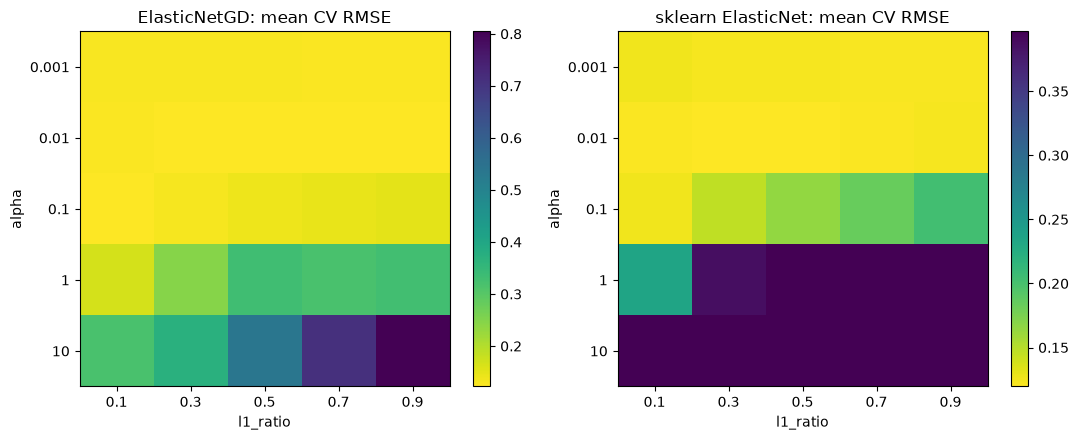

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, data, title in [
    (axes[0], en_gd_cv_mean, "ElasticNetGD"),
    (axes[1], en_sk_cv_mean, "sklearn ElasticNet"),
]:
    im = ax.imshow(data, aspect="auto", cmap="viridis_r")
    ax.set_xticks(range(len(l1_ratios)))
    ax.set_xticklabels(l1_ratios)
    ax.set_yticks(range(len(alphas_en)))
    ax.set_yticklabels([f"{a:.4g}" for a in alphas_en])
    ax.set_xlabel("l1_ratio")
    ax.set_ylabel("alpha")
    ax.set_title(f"{title}: mean CV RMSE")
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

## CV-selected vs. single-split-selected hyperparameters

The single-split values are hardcoded from `2_regularized_regression.ipynb`/`3_elastic_net.ipynb`'s own executed output (not re-derived) -- the point of this table is to see, per model, whether 5-fold CV agrees with the earlier single-split pick or found a different optimum.

In [8]:
best_ridge_gd_alpha = alphas_gd[np.argmin(ridge_gd_cv_mean)]
best_ridge_sk_alpha = alphas_sk[np.argmin(ridge_sk_cv_mean)]
best_lasso_gd_alpha = alphas_gd[np.argmin(lasso_gd_cv_mean)]
best_lasso_sk_alpha = alphas_gd[np.argmin(lasso_sk_cv_mean)]

best_en_gd_idx = np.unravel_index(np.argmin(en_gd_cv_mean), en_gd_cv_mean.shape)
best_en_sk_idx = np.unravel_index(np.argmin(en_sk_cv_mean), en_sk_cv_mean.shape)
best_en_gd_alpha, best_en_gd_l1_ratio = (
    alphas_en[best_en_gd_idx[0]], l1_ratios[best_en_gd_idx[1]],
)
best_en_sk_alpha, best_en_sk_l1_ratio = (
    alphas_en[best_en_sk_idx[0]], l1_ratios[best_en_sk_idx[1]],
)

comparison_df = pd.DataFrame(
    [
        {"model": "RidgeGD", "single-split alpha": 0.03162, "CV alpha": best_ridge_gd_alpha},
        {"model": "sklearn Ridge", "single-split alpha": 31.62, "CV alpha": best_ridge_sk_alpha},
        {"model": "LassoGD", "single-split alpha": 0.01, "CV alpha": best_lasso_gd_alpha},
        {"model": "sklearn Lasso", "single-split alpha": 0.003162, "CV alpha": best_lasso_sk_alpha},
        {
            "model": "ElasticNetGD", "single-split alpha": 0.01,
            "single-split l1_ratio": 0.7, "CV alpha": best_en_gd_alpha,
            "CV l1_ratio": best_en_gd_l1_ratio,
        },
        {
            "model": "sklearn ElasticNet", "single-split alpha": 0.01,
            "single-split l1_ratio": 0.3, "CV alpha": best_en_sk_alpha,
            "CV l1_ratio": best_en_sk_l1_ratio,
        },
    ]
).set_index("model")
comparison_df

,single-split alpha,CV alpha,single-split l1_ratio,CV l1_ratio
model,,,,
RidgeGD,0.031620,0.100000,NaN,NaN
sklearn Ridge,31.620000,177.827941,NaN,NaN
LassoGD,0.010000,0.010000,NaN,NaN
sklearn Lasso,0.003162,0.003162,NaN,NaN
ElasticNetGD,0.010000,0.010000,0.7,0.7
sklearn ElasticNet,0.010000,0.010000,0.3,0.3


## Refit each model at its CV-selected hyperparameters

One `build_pipeline()` fit on the entire `cv_pool` (not per-fold) -- the CV sweep above is only for hyperparameter selection; the final model is fit the normal way, same as notebooks 2/3's own "refit at best alpha" step.

In [9]:
pipeline_final = build_pipeline()
X_cv_pool = pipeline_final.fit_transform(cv_pool_raw).to_numpy()
X_holdout = pipeline_final.transform(holdout_raw).to_numpy()

ridge_gd_best = RidgeGD(
    learning_rate=0.01, batch_size=32, n_epochs=300,
    alpha=best_ridge_gd_alpha, random_state=42, verbose=True,
)
ridge_gd_best.fit(X_cv_pool, y_cv_pool)

ridge_sk_best = Ridge(alpha=best_ridge_sk_alpha)
ridge_sk_best.fit(X_cv_pool, y_cv_pool)

lasso_gd_best = LassoGD(
    learning_rate=0.01, batch_size=32, n_epochs=300,
    alpha=best_lasso_gd_alpha, random_state=42, verbose=True,
)
lasso_gd_best.fit(X_cv_pool, y_cv_pool)

lasso_sk_best = Lasso(alpha=best_lasso_sk_alpha)
lasso_sk_best.fit(X_cv_pool, y_cv_pool)

en_gd_best = ElasticNetGD(
    learning_rate=0.01, batch_size=32, n_epochs=300,
    alpha=best_en_gd_alpha, l1_ratio=best_en_gd_l1_ratio,
    random_state=42, verbose=True,
)
en_gd_best.fit(X_cv_pool, y_cv_pool)

en_sk_best = ElasticNet(alpha=best_en_sk_alpha, l1_ratio=best_en_sk_l1_ratio)
en_sk_best.fit(X_cv_pool, y_cv_pool)

linreg_gd_baseline = LinearRegressionGD(
    learning_rate=0.01, batch_size=32, n_epochs=300, random_state=42,
    verbose=True,
)
linreg_gd_baseline.fit(X_cv_pool, y_cv_pool)

linreg_sk_baseline = LinearRegression()
linreg_sk_baseline.fit(X_cv_pool, y_cv_pool)

MODELS = [
    ("LinearRegressionGD (baseline)", linreg_gd_baseline),
    ("sklearn LinearRegression (baseline)", linreg_sk_baseline),
    (f"RidgeGD (alpha={best_ridge_gd_alpha:.4g})", ridge_gd_best),
    (f"sklearn Ridge (alpha={best_ridge_sk_alpha:.4g})", ridge_sk_best),
    (f"LassoGD (alpha={best_lasso_gd_alpha:.4g})", lasso_gd_best),
    (f"sklearn Lasso (alpha={best_lasso_sk_alpha:.4g})", lasso_sk_best),
    (
        f"ElasticNetGD (alpha={best_en_gd_alpha:.4g}, "
        f"l1_ratio={best_en_gd_l1_ratio})",
        en_gd_best,
    ),
    (
        f"sklearn ElasticNet (alpha={best_en_sk_alpha:.4g}, "
        f"l1_ratio={best_en_sk_l1_ratio})",
        en_sk_best,
    ),
]

epoch 1/300 - loss: 32.6258
epoch 11/300 - loss: 0.0132
epoch 21/300 - loss: 0.0126
epoch 31/300 - loss: 0.0124
epoch 41/300 - loss: 0.0124
epoch 51/300 - loss: 0.0127
epoch 61/300 - loss: 0.0126
epoch 71/300 - loss: 0.0126
epoch 81/300 - loss: 0.0128
epoch 91/300 - loss: 0.0133
epoch 101/300 - loss: 0.0127
epoch 111/300 - loss: 0.0126
epoch 121/300 - loss: 0.0131
epoch 131/300 - loss: 0.0129
epoch 141/300 - loss: 0.0158
epoch 151/300 - loss: 0.0127
epoch 161/300 - loss: 0.0139
epoch 171/300 - loss: 0.0131
epoch 181/300 - loss: 0.0124
epoch 191/300 - loss: 0.0126
epoch 201/300 - loss: 0.0124
epoch 211/300 - loss: 0.0124
epoch 221/300 - loss: 0.0125
epoch 231/300 - loss: 0.0127
epoch 241/300 - loss: 0.0125
epoch 251/300 - loss: 0.0129
epoch 261/300 - loss: 0.0124
epoch 271/300 - loss: 0.0128
epoch 281/300 - loss: 0.0125
epoch 291/300 - loss: 0.0125
epoch 300/300 - loss: 0.0124
epoch 1/300 - loss: 32.6694
epoch 11/300 - loss: 0.0216
epoch 21/300 - loss: 0.0208
epoch 31/300 - loss: 0.0206

## Metrics table (final holdout)

RMSE in log space is the metric that actually matters (matches the Kaggle scoring); RMSE in dollar space (via `expm1`) and MAPE are for human-readable intuition.

In [10]:
metrics_rows = []
for name, model in MODELS:
    preds_log = model.predict(X_holdout)
    preds_dollars = np.expm1(preds_log)
    actual_dollars = np.expm1(y_holdout)
    mape = mean_absolute_percentage_error(actual_dollars, preds_dollars)
    metrics_rows.append(
        {
            "model": name,
            "RMSE (log space)": rmse(y_holdout, preds_log),
            "RMSE (dollars, intuition only)": rmse(
                actual_dollars, preds_dollars
            ),
            "R^2": r2_score(y_holdout, preds_log),
            "MAE (log space)": mean_absolute_error(y_holdout, preds_log),
            "MAPE (dollars, % of actual price)": 100 * mape,
        }
    )

metrics_df = pd.DataFrame(metrics_rows).set_index("model")
metrics_df

,RMSE (log space),"RMSE (dollars, intuition only)",R^2,MAE (log space),"MAPE (dollars, % of actual price)"
model,,,,,
LinearRegressionGD (baseline),0.129316,22150.880483,0.900801,0.089412,9.112843
sklearn LinearRegression (baseline),0.131956,21996.366199,0.896710,0.089983,9.127959
RidgeGD (alpha=0.1),0.126424,21960.372700,0.905188,0.089737,9.289559
sklearn Ridge (alpha=177.8),0.127123,22116.586206,0.904137,0.090408,9.367085
LassoGD (alpha=0.01),0.116306,19422.823774,0.919757,0.082283,8.517492
sklearn Lasso (alpha=0.003162),0.113262,19109.196989,0.923902,0.081730,8.410651
"ElasticNetGD (alpha=0.01, l1_ratio=0.7)",0.115441,19429.647187,0.920947,0.081893,8.461866
"sklearn ElasticNet (alpha=0.01, l1_ratio=0.3)",0.113979,19287.215011,0.922935,0.082237,8.466782


## Summary

**Did 5-fold CV agree with the single-split pick?** For 4 of the 6 regularized models, yes -- exactly:

| model | single-split | CV-selected | agreement |
|---|---|---|---|
| LassoGD | alpha=0.01 | alpha=0.01 | exact match |
| sklearn Lasso | alpha=0.003162 | alpha=0.003162 | exact match |
| ElasticNetGD | alpha=0.01, l1_ratio=0.7 | alpha=0.01, l1_ratio=0.7 | exact match |
| sklearn ElasticNet | alpha=0.01, l1_ratio=0.3 | alpha=0.01, l1_ratio=0.3 | exact match |
| RidgeGD | alpha=0.03162 | alpha=0.1 | ~3.2x higher, same order of magnitude |
| sklearn Ridge | alpha=31.62 | alpha=177.8 | ~5.6x higher, same order of magnitude |

Only the two Ridge variants moved -- both toward *more* regularization -- while every Lasso/ElasticNet model (GD and sklearn alike) landed on the identical hyperparameter CV would have picked from a single 80/20 split. That's a reassuring sign that the single-split choice in notebooks 2/3 wasn't a lucky/unlucky artifact of that one split for those four models; Ridge's shift suggests its single-split alpha was more split-sensitive, consistent with the CV curve for Ridge being comparatively flat over a wide alpha range (`ridge_gd_cv_mean`/`ridge_sk_cv_mean` change by <0.01 across nearly two orders of magnitude before rising sharply at the extremes) -- small differences in which rows land in train vs. validation can tip the observed minimum a step or two along that flat stretch.

**Did final-holdout RMSE improve? This comparison is structurally biased, and not in CV's favor.** This notebook's final holdout is the *exact same 292 rows* notebooks 2/3 used as their own single validation split -- the rows that split's alpha was picked to do well on. So notebooks 2/3's holdout numbers are optimistically biased by construction (they were tuned on the very data they're scored on), while this notebook's CV-selected alphas never saw those rows during selection at all. That means the numbers below cannot fairly adjudicate "did CV help or hurt" -- they can only show what each already-selected alpha does on this one particular split, which is a different question. A fair CV-vs-single-split comparison would need a third, never-touched split that neither procedure selected against (out of scope here, noted in the design spec as a future extension).

With that caveat: LassoGD/sklearn Lasso/ElasticNetGD/sklearn ElasticNet were refit at the exact same alpha (and l1_ratio) as notebooks 2/3, so their holdout `RMSE (log space)` is identical: 0.116306 / 0.113262 / 0.115441 / 0.113979, unchanged from notebooks 2/3. The two Ridge variants, refit at CV's higher alpha, saw holdout RMSE tick up slightly: RidgeGD 0.123382 -> 0.126424 (+0.003042) and sklearn Ridge 0.121564 -> 0.127123 (+0.005559). Given the bias above, this uptick is roughly what you'd expect from removing the single split's own selection advantage on these exact rows -- it is *not* evidence that CV's alpha generalizes worse, only that it wasn't chosen to fit this particular holdout the way notebooks 2/3's alpha implicitly was. Both remain well within the same ballpark as notebooks 2/3's numbers (LinearRegressionGD baseline 0.129316, sklearn LinearRegression baseline 0.131956). sklearn Lasso remains the best model on this holdout at RMSE (log space) = 0.113262 / R^2 = 0.923902, exactly as in notebooks 2/3 (unsurprising, since its alpha didn't change).

**Bottom line:** cross-validation mostly confirmed notebooks 2/3's single-split hyperparameter choices rather than overturning them -- for this dataset size (1166 CV-pool rows) and these alpha/l1_ratio grids, a single 80/20 split was already a reasonably stable way to pick alpha for Lasso and ElasticNet. Ridge was the exception, landing on a larger alpha (more regularization) under CV -- a choice made without ever looking at the holdout rows, unlike the single-split pick. Whether that CV choice is actually *better* for generalization can't be settled by this notebook's own holdout table, since that table is the same rows Ridge's single-split alpha was implicitly tuned against; it would take a further, untouched split to say so with confidence.
